In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from labdata.schema import UnitCount, SpikeSorting, DatasetEvents, Dataset, StreamSync


pd.set_option("display.max_columns", 100)

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data_path = Path("/Volumes/grb_ephys/data")
mouse = "GRB006"
session = "20240827_130938"  # this is the audio session
session_path = data_path / mouse / session

[2025-12-18 10:32:51,224][WARNING]: MySQL server has gone away. Reconnecting to the server.


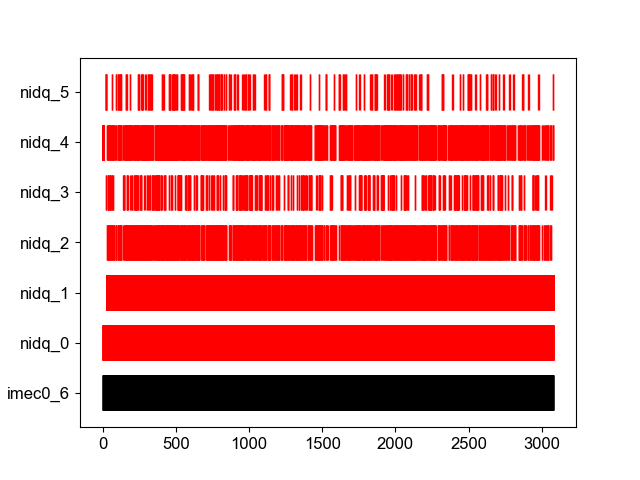

In [ ]:
dset = (Dataset() & 'session_name = "20240827_130938"').proj()
# in order for the events to be in sync, you need to provide a StreamSync row for that dataset
# see StreamSync & dset
events = DatasetEvents.Digital() & dset
# plot the events
plt.figure()
events.plot_synced()
# get event times
events = pd.DataFrame(events.fetch_synced())

In [37]:
# get synced spiketimes
units = SpikeSorting.Unit & (UnitCount.Unit & dset & "passes = 1")
unitspikes = pd.DataFrame(units.get_spike_times())

# get with metrics
unitmetrics = pd.DataFrame(units.get_spike_times(include_metrics=True))

In [38]:
# get the events for sync 4
ev = events[events.event_name == "3"].iloc[0]
# select only events with value 1 (rise)
ev_time = ev.event_timestamps[ev.event_values == 1]
# remove very fast events: noise
ev_time = ev_time[np.diff(np.hstack([0, ev_time])) > 0.005]
# align to event
trig = []
for u in unitspikes.unit_id.values:
    sp = unitspikes[unitspikes.unit_id == u].spike_times.iloc[0]
    tt = [sp[(sp > e - 0.1) & (sp < e + 0.1)] - e for e in ev_time]
    trig.append(tt)

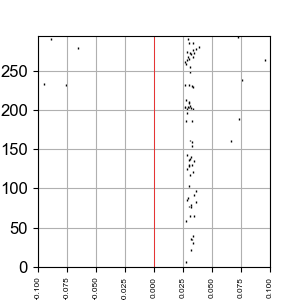

In [39]:
# plot a raster for an event
from spks import plot_raster

iunit = 61

fig = plt.figure(figsize=[3, 3])
plot_raster(trig[iunit], lw=1)
plt.xlim([-0.1, 0.1])
plt.grid()
plt.xticks(np.arange(-0.1, 0.11, 0.025), rotation=90, fontsize=6)
plt.vlines(0, 0, len(tt), linewidth=0.5, color="r");

In [40]:
StreamSync().insert1(
    dict(
        subject_name="GRB006",
        session_name="20240827_130938",
        dataset_name="ephys_g0",
        stream_name="imec0",
        event_name="6",
        clock_dataset="ephys_g0",
        clock_stream="nidq",
        clock_stream_event="0",
    )
)

DuplicateError: ("Duplicate entry 'GRB006-20240827_130938-ephys_g0-imec0-6-ephys_g0-nidq-0' for key 'stream_sync.PRIMARY'", 'To ignore duplicate entries in insert, set skip_duplicates=True')